<a href="https://colab.research.google.com/github/giacomomolinari/liar-fake-news-detector/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()


from datasets import load_dataset
from google.colab import drive
from pathlib import Path

## 1. Getting the Data

The notebook assumes that the LIAR dataset is available on your Google Drive at the path defined below. You can download the dataset from [William Yang Wang's website](https://sites.cs.ucsb.edu/~william/data/liar_dataset.zip).

In [ ]:
# Replace this with your path to the dataset
DATASET_PATH = Path("/content/drive/MyDrive/datasets/liar_dataset/")

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
columns= ["ID", "Label", "Statement", "Subjects", "Speaker", "SpeakerJob", "State", "Party",
          "HistBarelyTrue", "HistFalse", "HistHalfTrue", "HistMostTrue", "HistPantsFire", "Context"]

In [5]:
df_train = pd.read_csv(DATASET_PATH / "train.tsv", sep="\t", header=0, names=columns)

In [6]:
df_valid = pd.read_csv(DATASET_PATH / "valid.tsv", sep="\t", header=0, names=columns)

In [7]:
df_test = pd.read_csv(DATASET_PATH / "test.tsv", sep="\t", header=0, names=columns)

In [8]:
df_train.head()

,ID,Label,Statement,Subjects,Speaker,SpeakerJob,State,Party,HistBarelyTrue,HistFalse,HistHalfTrue,HistMostTrue,HistPantsFire,Context
0,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
1,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
2,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
3,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN
4,12465.json,true,The Chicago Bears have had more starting quart...,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion-piece


## 2. Exploring the Data

### 2.1 Exploring NaN entries

In [9]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10239 entries, 0 to 10238
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              10239 non-null  object 
 1   Label           10239 non-null  object 
 2   Statement       10239 non-null  object 
 3   Subjects        10237 non-null  object 
 4   Speaker         10237 non-null  object 
 5   SpeakerJob      7341 non-null   object 
 6   State           8029 non-null   object 
 7   Party           10237 non-null  object 
 8   HistBarelyTrue  10237 non-null  float64
 9   HistFalse       10237 non-null  float64
 10  HistHalfTrue    10237 non-null  float64
 11  HistMostTrue    10237 non-null  float64
 12  HistPantsFire   10237 non-null  float64
 13  Context         10137 non-null  object 
dtypes: float64(5), object(9)
memory usage: 1.1+ MB


For the most part the data is complete, although many rows have missing Party and State columns. This is likely because the claim's author does not hold an elected office, or is not a representative associated with a specific state.

In [10]:
df_train[df_train["SpeakerJob"].isna() | df_train["State"].isna()].head()

,ID,Label,Statement,Subjects,Speaker,SpeakerJob,State,Party,HistBarelyTrue,HistFalse,HistHalfTrue,HistMostTrue,HistPantsFire,Context
2,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
3,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN
5,2342.json,barely-true,Jim Dunnam has not lived in the district he re...,candidates-biography,republican-party-texas,NaN,Texas,republican,3.0,1.0,1.0,3.0,1.0,a press release.
7,5602.json,half-true,"However, it took $19.5 million in Oregon Lotte...",jobs,oregon-lottery,NaN,NaN,organization,0.0,0.0,1.0,0.0,1.0,a website
12,8616.json,mostly-true,The economy bled $24 billion due to the govern...,"economy,federal-budget,health-care",doonesbury,NaN,NaN,none,0.0,0.0,2.0,4.0,0.0,a Doonesbury strip in the Sunday comics


To begin with I will just remove these columns from the dataset for simplicity, as they are likely not among the most informative, and the project focuses on analyzing the statement text.


In [11]:
df_train.drop(columns=["SpeakerJob", "State"], inplace=True)


There are also about 100 statements which are missing context text.

In [12]:
df_train[df_train["Context"].isna()].shape

(102, 12)

In [13]:
df_train[df_train["Context"].isna()].head()

,ID,Label,Statement,Subjects,Speaker,Party,HistBarelyTrue,HistFalse,HistHalfTrue,HistMostTrue,HistPantsFire,Context
296,610.json,false,On using the Strategic Petroleum Reserve.,energy,barack-obama,democrat,70.0,71.0,160.0,163.0,9.0,NaN
372,5110.json,pants-fire,"Shes voted for 60 tax increases, hurting the m...",taxes,rob-cornilles,republican,1.0,1.0,3.0,1.0,1.0,NaN
379,10931.json,half-true,Since Republicans took over after the 2010 ele...,education,dale-kooyenga,republican,1.0,1.0,2.0,2.0,0.0,NaN
391,9784.json,true,On offshore drilling for energy,"energy,voting-record",mark-warner,democrat,3.0,1.0,6.0,3.0,0.0,NaN
643,645.json,half-true,Joe Biden brought Republicans and Democrats to...,crime,barack-obama,democrat,70.0,71.0,160.0,163.0,9.0,NaN


This appears to be just missing data. I will add custom text "No context provided." for these entries so that they are not NaN.

In [14]:
df_train.loc[df_train["Context"].isna(), "Context"]= "no context provided."

 There are too many possible values for this to be treated as a categorical variable. Instead, I will feed the Context field as input to an encoder RNN. I will then concatenate its output with that of the main RNN which receives the statement text as input, before feeding it to the output layer.


There are also two rows for which almost all features are empty:

In [15]:
df_train[df_train["Subjects"].isna()]

,ID,Label,Statement,Subjects,Speaker,Party,HistBarelyTrue,HistFalse,HistHalfTrue,HistMostTrue,HistPantsFire,Context
2141,638.json,false,The fact is that although we have had a presid...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no context provided.
9374,1626.json,false,"Joe, I keep hearing you every morning talking ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no context provided.


I will remove these rows for simplicity

In [16]:
df_train.drop(df_train[df_train["Subjects"].isna()].index, inplace=True)

### 2.2 Exploring the Labels

(array([2114.,    0., 1962.,    0., 1992.,    0., 1676.,    0., 1654.,
         839.]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]),
 <BarContainer object of 10 artists>)

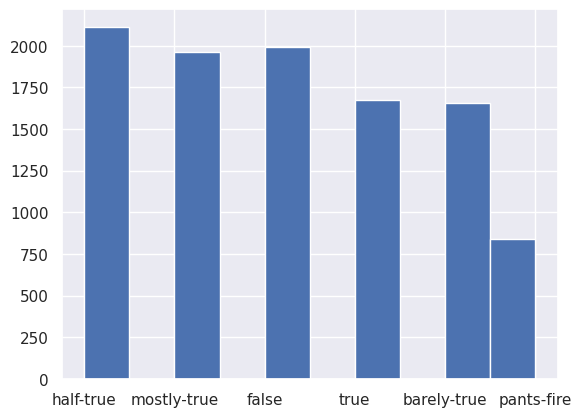

In [89]:
plt.hist(df_train["Label"], align="mid")

There are several interesting things to note here:
1. The distribution of labels is fairly uniform, except for the pants-fire (i.e. the most extraordinary lies) being about half as common as the other categories. This may need to be taken into account when scoring the model accuracy in training.
2. There is an obvious ordering between labels, with pants-fire < false < barely-true  < half-true < mostly-true < true. It is worth taking this into account, for example by using an ordinal loss when training or evaluating the model, so that e.g. predicting "false" is worse than predicting "mostly-true" when the target is "true".
3. The pants-fire category is potentially problematic. It seems to capture something like the obviousness, brazenness, or shock-value of the lie. It is questionable whether a disinformation detector ought to care about such features. Therefore, I will consider merging this category with "false". An added benefit of doing so will be that we get a symmetrical scale of truthfulness: false < barely-true  < half-true < mostly-true < true, with "half-true" in the exact middle.

### 2.2 Exploring The Metadata

As we saw above, the dataset provides several features beyond the text of the statement being evaluated.

#### 2.2.1 Party affiliation

In [18]:
df_train.groupby("Party").count()

,ID,Label,Statement,Subjects,Speaker,HistBarelyTrue,HistFalse,HistHalfTrue,HistMostTrue,HistPantsFire,Context
Party,,,,,,,,,,,
Moderate,1,1,1,1,1,1,1,1,1,1,1
activist,39,39,39,39,39,39,39,39,39,39,39
business-leader,9,9,9,9,9,9,9,9,9,9,9
columnist,35,35,35,35,35,35,35,35,35,35,35
constitution-party,1,1,1,1,1,1,1,1,1,1,1
democrat,3336,3336,3336,3336,3336,3336,3336,3336,3336,3336,3336
democratic-farmer-labor,1,1,1,1,1,1,1,1,1,1,1
education-official,2,2,2,2,2,2,2,2,2,2,2
government-body,1,1,1,1,1,1,1,1,1,1,1


The overwhelming majority of entries are split between Republican, Democrat, and none, with similar counts of samples for the two main parties. It may be worth aggregating some of the parties with very few instances, or the non-party designations (e.g. "journalist", "columnist", "talk-show-host").

Let's look at the three most common categories in more detail.

In [19]:
df_grouped_by_party_label = df_train.loc[df_train["Party"].isin(["democrat", "republican", "none"])].groupby(["Party", "Label"])[["ID"]].count()
df_grouped_by_party_label

ID
Party      Label            
democrat   barely-true   463
           false         511
           half-true     750
           mostly-true   801
           pants-fire    153
           true          658
none       barely-true   261
           false         326
           half-true     327
           mostly-true   315
           pants-fire    269
           true          246
republican barely-true   832
           false        1027
           half-true     890
           mostly-true   707
           pants-fire    380
           true          660

There is a significant difference here in the distribution of the various labels based on party

In [20]:
# It helps for data visualization to order the label by most extreme lie to truth
ordered_label = ["pants-fire", "false", "barely-true", "half-true", "mostly-true", "true"]

In [21]:
df_select_party_label = df_train[df_train["Party"].isin(["democrat", "republican", "none"])][["Party", "Label"]]
df_select_party_label['Label'] = pd.Categorical(df_select_party_label['Label'], categories=ordered_label, ordered=True)

df_democrat_labels = df_select_party_label[df_select_party_label["Party"]=="democrat"]["Label"]

df_republican_labels = df_select_party_label[df_select_party_label["Party"]=="republican"]["Label"]

df_noparty_labels = df_select_party_label[df_select_party_label["Party"]=="none"]["Label"]


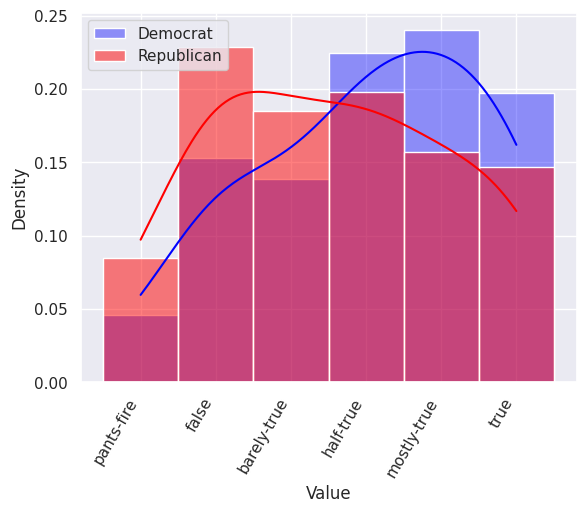

In [22]:
sns.histplot(data=df_democrat_labels, color='blue', alpha=0.4, kde="true", kde_kws={"bw_adjust": 2.5}, label='Democrat', stat="density")
sns.histplot(data=df_republican_labels, color='red', alpha=0.5, kde="true", kde_kws={"bw_adjust": 2.5}, label='Republican', stat="density")

plt.xlabel('Value')
plt.xticks(rotation=60, ha='right')
plt.ylabel('Density')
plt.legend()
plt.show()

We can see a considerable difference in the distribution of labels between the two main parties

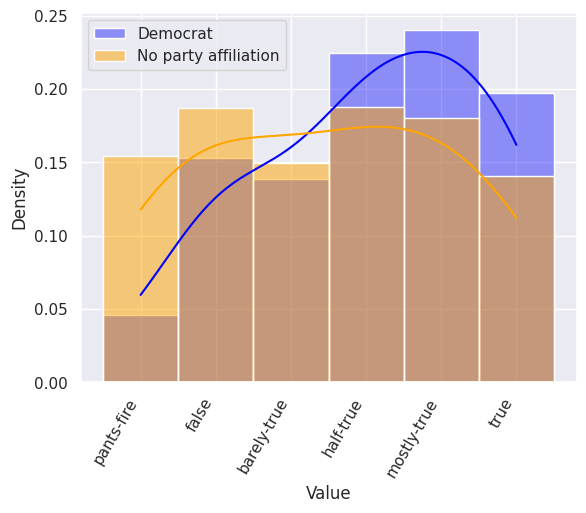

In [23]:
sns.histplot(data=df_democrat_labels, color='blue', alpha=0.4, kde="true", kde_kws={"bw_adjust": 2.5}, label='Democrat', stat="density")
sns.histplot(data=df_noparty_labels, color='orange', alpha=0.5, kde="true", kde_kws={"bw_adjust": 2.5}, label='No party affiliation', stat="density")

plt.xlabel('Value')
plt.xticks(rotation=60, ha='right')
plt.ylabel('Density')
plt.legend()
plt.show()

And again between democrats and no-party

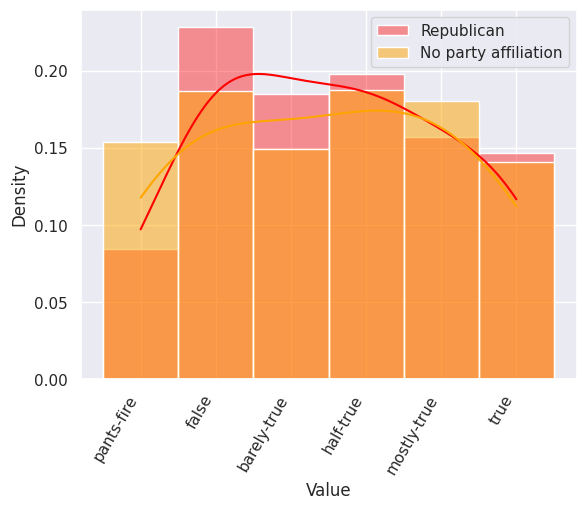

In [24]:
sns.histplot(data=df_republican_labels, color='red', alpha=0.4, kde="true", kde_kws={"bw_adjust": 2.5}, label='Republican', stat="density")
sns.histplot(data=df_noparty_labels, color='orange', alpha=0.5, kde="true", kde_kws={"bw_adjust": 2.5}, label='No party affiliation', stat="density")

plt.xlabel('Value')
plt.xticks(rotation=60, ha='right')
plt.ylabel('Density')
plt.legend()
plt.show()

There is less radical difference between Republican and no-party, except for the left of the distribution, where no-party has a higher density of "pants-fire" level lies, whereas republicans have higher density of false or barely-true claims.

This may be related to the issues with the "pants-fire" category we noted above. The category may be capturing something like shock-value or brazenness, and false statements embraced by either of the main two parties may seem less shocking/brazen to a (well-meaning) fact-checker than those embraced only by the more marginal/niche political figures.

Unfortunately, there is little information about how this data was sampled from the fact-checker website (and even less about the sampling method of the fact-checker website itself, i.e. how fact-checkers select which claims to test). Because of this, it is quite possible that the bias in the data does not reflect actual features of the underlying distribution, but merely selection bias.

Addressing this problem is beyond the scope of my project. Still, it is worth comparing what a predictor can do:
1.  using only metadata (such as party affiliation), versus
2. using only textual data (statement or statement + context), versus
3. using both.

#### 2.2.2 Subjects

In [25]:
df_grouped_subject = df_train.groupby("Subjects")["ID"].count()

df_grouped_subject.sort_values(ascending=False)

,ID
Subjects,
health-care,381
taxes,308
immigration,253
elections,252
education,237
...,...
"corporations,message-machine,state-budget,taxes,workers",1
"corporations,message-machine,taxes",1
"corporations,message-machine-2014,taxes,voting-record,wealth",1


Much like for Context, we have textual data that cannot easily be converted to categorical. But here the data is structured, which gives us a few more options. For example, we could try to collect all possible tags and then represent each Subjects entry as a vector of 0s and 1s, with 1s for all tags that are included. This is basically a multi-hot representation of the Subject feature.

In [26]:
subject_set = set([])
subject_series = []
for subject in df_train["Subjects"]:
  if not isinstance(subject, str):
    print(subject)
  subject = subject.replace(", ", ",")
  split = subject.split(",")
  for s in split:
    if s not in subject_set:
      subject_set.add(s)
    subject_series.append(s)

In [27]:
len(subject_set), len(subject_series)

(142, 22202)

In [28]:
subject_series = pd.Series(subject_series)
counts = subject_series.value_counts()
counts[counts > 10].count()

np.int64(130)

Only 130 subject categories appear more than 10 times in the dataset. I will ignore subjects that appear less than 10 times to reduce noise.

To get a sense of whether and how these Subject tags correlate with the truthfulness labels, let's look a the most frequent ones:

In [29]:
counts[counts > 300].count()

np.int64(18)

18 Subject tags appear over 300 times

In [30]:
common_subjects = set(counts[counts > 300].index)
common_subjects

{'candidates-biography',
 'crime',
 'economy',
 'education',
 'elections',
 'energy',
 'environment',
 'federal-budget',
 'foreign-policy',
 'guns',
 'health-care',
 'history',
 'immigration',
 'jobs',
 'legal-issues',
 'military',
 'state-budget',
 'taxes'}

In [31]:
df_common_subjects = df_train[df_train["Subjects"].isin(common_subjects)].copy()
df_common_subjects = df_common_subjects[["Subjects", "Label"]]
df_common_subjects.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2595 entries, 1 to 10235
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Subjects  2595 non-null   object
 1   Label     2595 non-null   object
dtypes: object(2)
memory usage: 60.8+ KB


In [32]:
df_immigration = pd.Categorical(df_common_subjects[df_common_subjects["Subjects"] == "immigration"]["Label"], categories=ordered_label, ordered=True)

df_economy = pd.Categorical(df_common_subjects[df_common_subjects["Subjects"] == "economy"]["Label"], categories=ordered_label, ordered=True)

df_politics = pd.Categorical(df_common_subjects[df_common_subjects["Subjects"] == "history"]["Label"], categories=ordered_label, ordered=True)

df_military = pd.Categorical(df_common_subjects[df_common_subjects["Subjects"] == "military"]["Label"], categories=ordered_label, ordered=True)

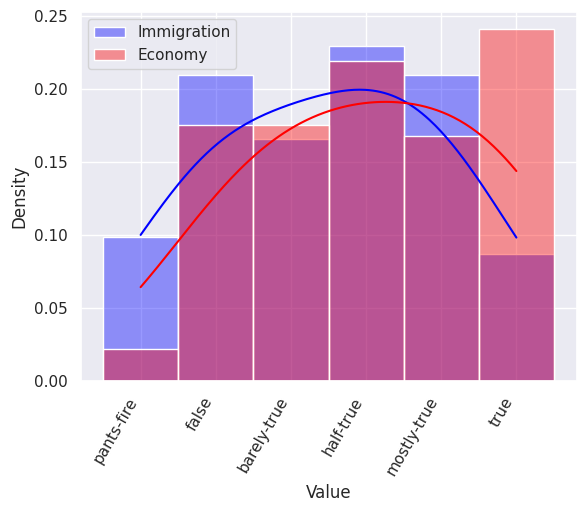

In [33]:
sns.histplot(data=df_immigration, color='blue', alpha=0.4, kde="true", kde_kws={"bw_adjust": 2}, label='Immigration', stat="density")
sns.histplot(data=df_economy, color='red', alpha=0.4, kde="true", kde_kws={"bw_adjust": 2}, label='Economy', stat="density")

plt.xlabel('Value')
plt.xticks(rotation=60, ha='right')
plt.ylabel('Density')
plt.legend()
plt.show()

Some important differences about these two claims, with claims about the economy far more likely to be truths than claims about immigration, who are more commonly somewhere on the falsity scale.

<Axes: ylabel='Density'>

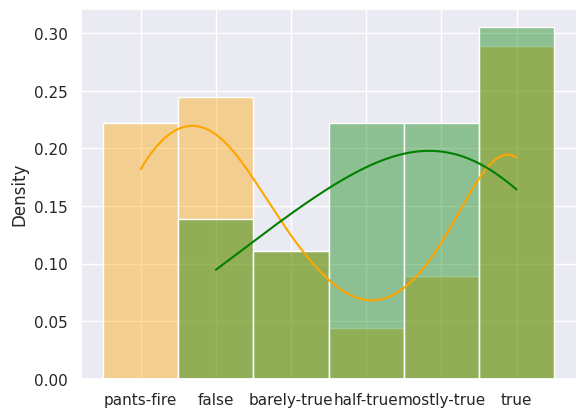

In [34]:
sns.histplot(data=df_politics, color='orange', alpha=0.4, kde="true", kde_kws={"bw_adjust": 0.7}, label='History', stat="density")
sns.histplot(data=df_military, color='green', alpha=0.4, kde="true", kde_kws={"bw_adjust": 2}, label='Military', stat="density")


This plot shows some very significant differences between Subject categories . Interestingly, no claim about the military in the training set has been classified as "pants-fire" (likely because military matters were, at the time, a relatively non-partisan feature of American political discourse). On the other hand, claims about History tend to be either false or true, with little room for misleading half-truths.

#### 2.2.3 Speaker and History

The dataset includes information about the speaker (or organization) who made the claim, as well as their history of trutfulness, i.e. the number of claims with various truthfulness labels from the same speaker which are included in the dataset.

This information can obviously tell the model quite a bit about the truthfulness of the statement in question, since it is frequency information about the speaker's truthfulness.

Also, as the dataset authors point out, information about the label of the current statement is included in the history counts. So e.g. when the sample is a False statement by Mitt Romney, the HistFalse value is the number of False statements by Mitt Romney in the dataset, **including the current one**.

In [35]:
df_train[df_train["Speaker"] == "donald-trump"][["HistPantsFire", "HistFalse"	, "HistBarelyTrue",	 "HistHalfTrue"	, "HistMostTrue"]].iloc[0,:]

,56
HistPantsFire,61.0
HistFalse,114.0
HistBarelyTrue,63.0
HistHalfTrue,51.0
HistMostTrue,37.0


In [36]:
train_counts = df_train[df_train["Speaker"] == "donald-trump"].groupby("Label")["ID"].count()
valid_counts = df_valid[df_valid["Speaker"] == "donald-trump"].groupby("Label")["ID"].count()
test_counts = df_test[df_test["Speaker"] == "donald-trump"].groupby("Label")["ID"].count()

train_counts + valid_counts + test_counts

,ID
Label,
barely-true,63
false,117
half-true,51
mostly-true,37
pants-fire,61
true,14


The above cells show the history of Mitt Romney's statements provided within a single sample of one of its statements, and the count of all Mitt Romney statements' labels across the whole dataset. The two DataFrames are identical: the historcal data is just the count of all statement labels for Mitt Romney's statments across the whole database.

This means that the historical feature of each sample contain both information about that sample's label, and information about frequency of labels for that sample's speaker in both the validation and test datasets. This violates principles of data separation between features and target, and between training and validation/test sets. Therefore it seems best to completely remove these historical features from the dataset when training and evaluating our model.

In [37]:
df_trump = pd.Categorical(df_train[df_train["Speaker"] == "donald-trump"]["Label"], categories=ordered_label, ordered=True)
df_obama = pd.Categorical(df_train[df_train["Speaker"] == "barack-obama"]["Label"], categories=ordered_label, ordered=True)

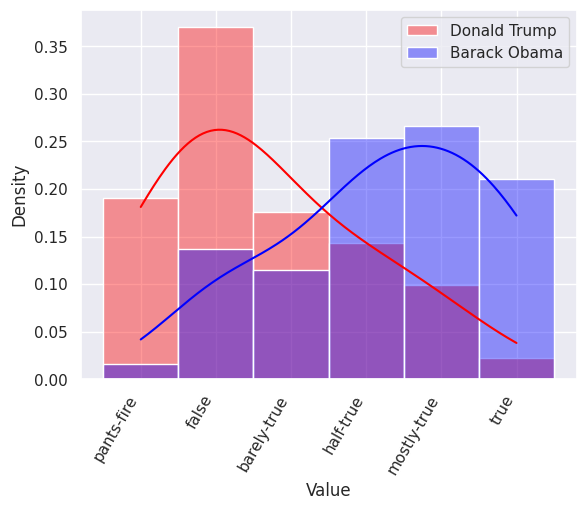

In [38]:
sns.histplot(data=df_trump, color='red', alpha=0.4, kde="true", kde_kws={"bw_adjust": 2}, label='Donald Trump', stat="density")
sns.histplot(data=df_obama, color='blue', alpha=0.4, kde="true", kde_kws={"bw_adjust": 2}, label='Barack Obama', stat="density")

plt.xlabel('Value')
plt.xticks(rotation=60, ha='right')
plt.ylabel('Density')
plt.legend()
plt.show()

As expected, speaker information can be quite strongly correlated with distribution of labels. As for the political party, it's hard to say whether this reflects genuine features of the underlying distribution or whether it is due to sampling bias either from the makers of the dataset, or from the fact checker's websites.

As for other metadata, addressing questions around bias of data-collection goes beyond the scope of this project. Still, these correlations between metadata and label further motivate studying how well a model trained on metadata can perform versus a model that only has access to text, versus a model that uses both text and metadata.

#### 2.2.4 Exploring the Statement length distribution

In [70]:
df_train["StatementLength"] = df_train["Statement"].apply(lambda x: len(x.split(" ")))
df_train.head()

,ID,Label,Statement,Subjects,Speaker,Party,HistBarelyTrue,HistFalse,HistHalfTrue,HistMostTrue,HistPantsFire,Context,StatementLength
0,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,24
1,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,democrat,70.0,71.0,160.0,163.0,9.0,Denver,19
2,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,none,7.0,19.0,3.0,5.0,44.0,a news release,12
3,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN,10
4,12465.json,true,The Chicago Bears have had more starting quart...,education,robin-vos,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion-piece,27


<Axes: xlabel='StatementLength', ylabel='Density'>

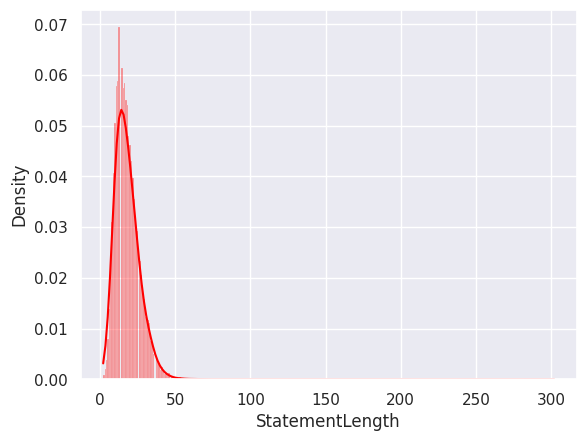

In [71]:
sns.histplot(data=df_train["StatementLength"], color='red', alpha=0.4, kde="true", kde_kws={"bw_adjust": 2}, label='Statement Length', stat="density")


The distribution has an extremely long tail, which could be a problem, as our RNNs are unlikely to behave well for very long sequences. Let's get a better sense of these outliers.

In [72]:
std = df_train["StatementLength"].std()
mean = df_train["StatementLength"].mean()
mode = df_train["StatementLength"].mode().iat[0]

mean,mode, std

(np.float64(17.9647357624304), np.int64(13), 8.528234315511863)

We can see the mean is noticeably higher than the mode, and the variance is quite high as well.

In [73]:
mean + 4*std, df_train[df_train["StatementLength"] > mean + 4*std]["ID"].count()

(np.float64(52.07767302447785), np.int64(17))

In [88]:
df_train[df_train["StatementLength"] > mean + 4*std]["StatementLength"].sort_values(ascending=False)

,StatementLength
1279,302
7549,199
6118,142
4192,66
9961,65
426,61
5025,60
1274,60
4033,57
7408,55


In [74]:
mean + 3*std, df_train[df_train["StatementLength"] > mean + 3*std]["ID"].count()

(np.float64(43.549438708965994), np.int64(59))

In [75]:
mean + 2*std, df_train[df_train["StatementLength"] > mean + 2*std]["ID"].count()

(np.float64(35.02120439345413), np.int64(280))

We can see that very few statements are longer than the mean by 3-4 times the standard deviation. In a training set of 10,000 entries it seems a reasonable tradeoff to keep sequences shorter (since we'll have to pad them all to the same length) at the price of losing a hundred or so datapoints. So I will limit the length of statements to 40 words, which will cost us about 100 samples.

In [82]:
df_train[df_train["StatementLength"] > 40]["ID"].count()

np.int64(108)

In [83]:
df_short_statements = df_train[df_train["StatementLength"] <= 40]

<Axes: xlabel='StatementLength', ylabel='Density'>

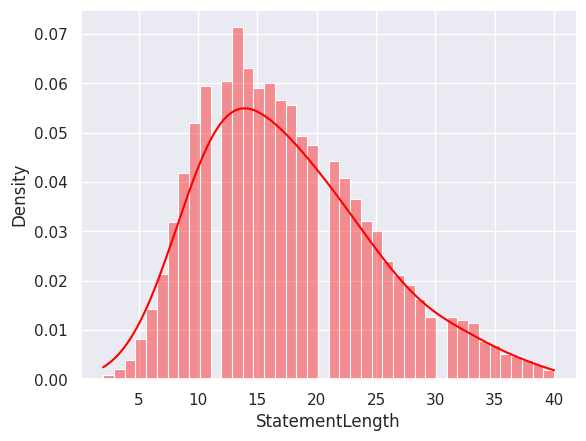

In [85]:
sns.histplot(data=df_short_statements["StatementLength"], color='red', alpha=0.4, kde="true", kde_kws={"bw_adjust": 2}, label='Statement Length', stat="density")


This now looks like a slightly skewed normal distribution.

## 3. Summary of EDA

From the above data analysis we can draw a number of conclusions about the task at hand, the dataset, and how the model should be set up.
- The dataset is mostly complete, but two columns (`SpeakerJob` and `State`) have several null entries. For simplicity, we will initially ignore such features in our model.
- There are about a hundred entries with empty `Context` column. I will fill these cells with the string "no context provided." and use them in training and evaluation.
-  The labels are fairly evenly distributed, but the `pants-on-fire` category is potentially problematic. It makes the labels asymmetric (half-true is not halfway between the most and least truthful label) and could be encoding some facts about whether the statement is considered obscene, extraordinary, or just surprising, which are arguably not what a lie-detector should be trained to recognize. Therefore, I will merge the `pants-on-fire` category with the `false` category.
- There is a natural ordering between labels in terms of degrees of truthfulness (false < barely true < ... < true) which should be taken into account when evaluating the model, e.g. by using an ordinal classification loss function.
- `Party` and `Subject` features can sometimes be strongly correlated with the statement label. It is beyond the scope of this project to determine whether this is due to genuine features of the underlying distribution, or whether this is due to sampling bias by the dataset's authors, or by the original fact-checker website.  However, since this is potentially valuable information for our task, it is worth training a separate model using only this metadata and comparing it with a model trained only on the textual data, as well as combining the two.
- The "speaker history" fields are shown to provide a total count of the speaker's statements for each truthfulness label in the dataset, across both train, validation, and test sets. This risks data leakage and therefore these features will not be used to train and evaluate my models.
- The statement length has a mode of 15 words, but there are outliers that contain statements of hundreds of words. I will remove all statements with over 40 words from the dataset, since this ends up removing only about 100 statements, and reduces the amount of padding necessary to ensure that all sequences processed by the RNN (within a batch) have the same length. This in turn reduces the risk of the RNN forgetting much of the sequence's information after it is done processing the padding. After removing statements of over 40 words, the statement length takes a slightly skewed but approximately normal distribution around the mode.